### Classification in DeepLearning

### Problem Statement 
- predict if a patient will face any heairing diseases using the age and the physical score of a hearing test

#### Import thr required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

### Load The DATa

In [2]:
df = pd.read_csv("hearing_test.csv")
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


### EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [4]:
# Perform the corelation Analysis
df.corr()  # it does not matter in the DL due to the activation Function

,age,physical_score,test_result
age,1.000000,-0.782146,-0.683171
physical_score,-0.782146,1.000000,0.792716
test_result,-0.683171,0.792716,1.000000


### Data Preprocessing

In [5]:
# Check if the Dataset is balanced
df['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

In [6]:
x = df.drop('test_result',axis=1)
y = df['test_result']

In [7]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x,y = smote.fit_resample(x,y)

In [8]:
y.value_counts()

test_result
1    3000
0    3000
Name: count, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

## Deep Learning

### check if GPU is available

In [10]:
# Find the deviece if any
device = 'cpu'

if torch.backends.mps.is_available():
    device='mps' #mps (metal performance sharder)
elif torch.cuda.is_available():
    device = 'cuda' # cuda (compute unified device architecture)
else:
    device='cpu'

print(f" founded device : {device} ")

 founded device : cuda 


In [11]:
#convert the the datasets to the tensors
# Dataframes cannot convert directly we need to .values
x_train = torch.FloatTensor(x_train.values).to(device)
x_test = torch.FloatTensor(x_test.values).to(device)
y_train = torch.FloatTensor(y_train.values).unsqueeze(1).to(device)
y_test = torch.FloatTensor(y_test.values).unsqueeze(1).to(device)

In [12]:
x_train.ndim ,y_train.ndim

(2, 2)

### Build the Deep Learning Model

In [13]:
# Create the model using sequential
model = torch.nn.Sequential(
    # create the input layer of 2 neurons and hidden layer is 16 neurons
    torch.nn.Linear(in_features=2,out_features=16),

    # Set the RELu as activation Function
    torch.nn.ReLU(),

    # Create Hidden with 8 Neurons :
    torch.nn.Linear(in_features=16,out_features=8),
    torch.nn.ReLU(),

    #Create the output layer with 1 Neuron : 
    torch.nn.Linear(in_features=8,out_features=1),
    #It is the Binary Classification Use the Sigmoid as Activation Function
    torch.nn.Sigmoid()
)

In [14]:
# Move the Model to the GPU
model = model.to(device)

In [15]:
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


### Set the Hyper Parameters 

In [16]:
# number of epochs
epochs = 100
#learning Rate 
lr=0.01
#loss Function
loss_function = torch.nn.BCELoss()

# Set the optimizer
optimizer  = torch.optim.Adam(model.parameters(),lr=lr)

### Training Loop

In [17]:
losses = [] #Collect all losses
accuracy_metrics = []  #collect all accuracyes
for epoch in range(epochs):

    #Enable the train mode
    model.train()

    # Predict the answers for the x_train
    # The Entire data can load in the memory in the at once so for bigger data it crashesh
    # so use Data loader for it
    y_pred = model(x_train)

    # Reset the Gradients
    optimizer.zero_grad()

    # Calculate the loss
    loss = loss_function(y_pred,y_train)

    # Cal the loss Gradients 
    loss.backward()

    #Update the Weights
    optimizer.step()

    #Get the Accuracies : 
    prediction_classes = (y_pred >=0.5).float()
    accuracy = (prediction_classes==y_train).float().mean()
    accuracy_metrics.append(accuracy.item())
    
    #collect the losses : 
    losses.append(loss.item())
    if (epoch+1) %10==0 :
        print(f" {epoch+1} loss : {loss} accuracy : {accuracy} ") #weight : {model.parameters[0]}  bais : {model.parameters[1]}")

 10 loss : 0.8981528878211975 accuracy : 0.5008333325386047 
 20 loss : 0.3788163363933563 accuracy : 0.8300000429153442 
 30 loss : 0.31200775504112244 accuracy : 0.8666666746139526 
 40 loss : 0.2639060914516449 accuracy : 0.8912500143051147 
 50 loss : 0.24664917588233948 accuracy : 0.8989583253860474 
 60 loss : 0.24072681367397308 accuracy : 0.9010416865348816 
 70 loss : 0.2385377287864685 accuracy : 0.9010416865348816 
 80 loss : 0.23781318962574005 accuracy : 0.9014583826065063 
 90 loss : 0.2375839799642563 accuracy : 0.9010416865348816 
 100 loss : 0.2372891753911972 accuracy : 0.9008333683013916 


### Visualize the Training Loss

Text(0.5, 1.0, 'Training Loss')

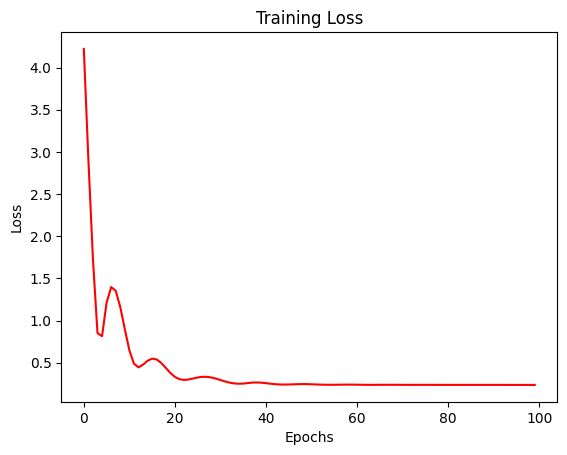

In [18]:
plt.plot(np.arange(epochs),losses,color ='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Training Loss")

### Visualize the Accuracy

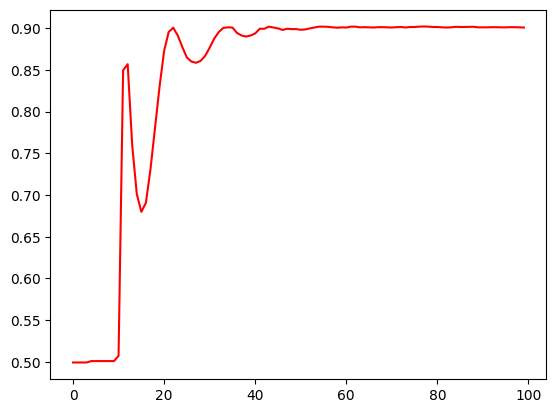

In [19]:
plt.plot(np.arange(epochs),accuracy_metrics,color = 'red')

### Evaluate the Model

In [20]:
# Enables the evaluation Mode : 
model.eval() 
# Desable the Training Prameters 
with torch.no_grad():
    y_pred = model(x_test)
    prediction_classes = (y_pred >= 0.5).float()  
    accuracy = (prediction_classes==y_test).float().mean() # This Opreation done on the GPU
print(accuracy)

tensor(0.8825, device='cuda:0')


In [21]:
# Since the accuracy_score doesnot support the tensor running on the gpu 
# We need to bring them on the CPU to calculate it
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

accuracy = accuracy_score(y_test.cpu(),prediction_classes.cpu())
precision = precision_score(y_test.cpu(),prediction_classes.cpu())
recall = recall_score(y_test.cpu(),prediction_classes.cpu())
f1 = f1_score(y_test.cpu(),prediction_classes.cpu())
print(f"Accuracy : {accuracy :.2f}")
print(f"Precision : {precision :.2f}")
print(f"Recall : {recall :.2f}")
print(f"F1 : {f1 :.2f}")

Accuracy : 0.88
Precision : 0.88
Recall : 0.89
F1 : 0.88
